# Load in Packages

In [1]:
import numpy as np
import matplotlib as mpl
import matplotlib.pyplot as plt
import matplotlib.colors as col
from matplotlib.colors import PowerNorm
from matplotlib.patches import Rectangle
from matplotlib.ticker import FormatStrFormatter
#from skimage.draw import disk
from scipy.optimize import curve_fit
from scipy import signal
from scipy.fft import fft, fftshift
from scipy.signal import fftconvolve
#from lmfit import Parameters, minimize, report_fit
from obspy.imaging.cm import viridis_white
import cmocean
import xarray as xr
from math import nan
import multiprocessing

import sys, os
sys.path.append(os.path.abspath("R:\Lawson\mpes-analysis"))  # or full path to project
#sys.path.append(os.path.abspath("R:\Lawson\mpes-analysis"))  # or full path to project

from Loader import DataLoader
from Main import main
from Manager import DataHandler, FigureHandler, PlotHandler, ValueHandler, SliderManager, EventHandler, CheckButtonManager, ClickButtonManager
import mpes
from mpes import cmap_LTL, cmap_LTL2
%load_ext autoreload
%autoreload 2

c:\Users\lloyd\Anaconda3\lib\site-packages\obspy\core\util\base.py:26: UserWarning: pkg_resources is deprecated as an API. See https://setuptools.pypa.io/en/latest/pkg_resources.html. The pkg_resources package is slated for removal as early as 2025-11-30. Refrain from using this package or pin to Setuptools<81.
  import pkg_resources


# Load the Data
### Specify Filename and Path. Load the Data

In [2]:
# Specify datapath, filename, and [Energy, Delay] offsets to load.
data_path = 'R:\Lawson\Data\metis'
#data_path = '/Users/lawsonlloyd/Desktop/Data/metis'

filename, offsets = 'Scan162_RT_120x120x115x50_binned.h5', [0.8467, -120]
#filename, offsets = 'Scan162_RT_120x120x115x51_rebinned_newECAL.h5', [0.035, 0]

#filename, offsets = 'Scan163_120K_120x120x115x75_binned.h5',  [0.6369, -132]
#filename, offsets = 'Scan163_120K_101x101x131x77_binned_v3.h5',  [0, 0]
#filename, offsets = 'Scan163_120K_101x101x131x77_binned_v4.h5',  [-.161, 0]
#filename, offsets = 'Scan163_120K_tofshifted_binned.h5', [-0.1, 0]
#filename, offsets = 'Scan186_120K_Static_120x120x200_binned.h5', [0.039, 0]
#filename, offsets = 'Scan188_120K_120x120x115x77_binned.h5', [0.5660, -105]

# Load the Data
data_loader = DataLoader(data_path + '//' + filename, offsets = offsets)
I = data_loader.load()


The data shape is: (120, 120, 115, 50)
"R:\Lawson\Data\metis//Scan162_RT_120x120x115x50_binned.h5" has been loaded! Happy Analysis...


### Generate Normalized and Difference Data


In [3]:
# Normalize Each Time Step to the Total Volume Counts, if desired

norm_each_time_step = True

if norm_each_time_step is True:
    I = I / I.loc[{"E":slice(-5,-1)}].sum(dim=('kx','ky','E'))

I = I/np.max(I)

# Truncate and Normalize Data, if desired.
#I = I.loc[{"delay":slice(-250,850)}]
I_res = I[:, :, :, 1:-2] # Clip the end points to account for binning artifact
I_res = I_res/np.max(I_res) #Normalize the dataset

# Generate Difference Data (Pos - Neg Delay Times), if desired.
if "delay" in I.dims:
    I_diff = I_res - I_res.loc[{"delay":slice(-300,-100)}].mean(dim="delay")
    I_diff = I_diff/np.max(I_diff)

# CrSBr lattice constant and High Symmetry Points.
a, b = 3.508, 4.763 # CrSBr values
X, Y = np.pi/a, np.pi/b
x, y = -2*X, 0

# Analysis and Visualization: Fourier Transform of Momentum Space Signature

### Plot Momentum Maps at Constant Energy

0.002195810402083858


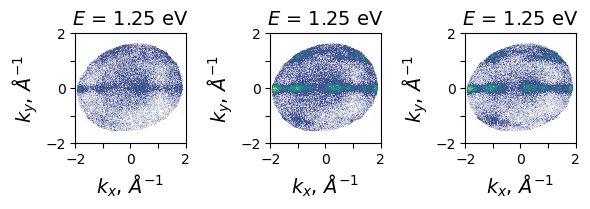

In [4]:
E, E_int = 1.25, .2
#delays, delay_int = 500, 1000

norm_frame = mpes.get_momentum_map(I_res, E, E_int, delay=250, delay_int=100)
norm = norm_frame.max()
print(norm.values)

fig, ax, im = mpes.plot_momentum_maps(
    I_res, E=E, E_int=E_int, delays=[0, 100, 500], delay_int=100,
    cmap=cmap_LTL, scale=[0, 1],
    fontsize=14, figsize=(6, 3), colorbar=False, panel_labels = False, norm_to=norm
)

#mpes.overlay_bz('rectangular', 3.508, 4.763, ax[0], 'black', rotation_deg = 0, repeat = 0)
#mpes.overlay_bz('hexagonal', 5.8, 5.8, ax[0], 'black', repeat = 2, rotation_deg = 90)
#mpes.save_figure(fig, name = f'scan186', image_format = 'svg')

#### Extract k-space frames and perform initial 2D FFT to real space

In [ ]:
# Do the 2D FFT of MM to Extract Real-Space Information

%matplotlib inline

a, b = 3.508, 4.763 # CrSBr values
X, Y = np.pi/a, np.pi/b
x, y = -2*X, 0*Y

E, E_int  = 1.25, 0.150 #Energy and total width in eV
#E, E_int  = 1.35, 0.100 #Energy and total width in eV

fwhm_kspace_res = 0.063
#fwhm_kspace_res = 0.075

ky, ky_int = 0, 2
delays, delay_int = 600, 800 

win_type = 1 #0, 1 = 2D Tukey, 2, 3
alpha = 0.5
zeropad = 2048

frame_pos = mpes.get_momentum_map(I_res, E, E_int, delays, delay_int)  # Get Positive Delay MM frame (takes mean over ranges)
frame_neg = mpes.get_momentum_map(I_res, E, E_int, -130, 50) # Get Negative Delay MM frame (takes mean over ranges)
frame_diff = frame_pos - frame_neg

testing = 0
if testing == 1:
    ax_kx, ax_ky = np.linspace(-2,2,120), np.linspace(-2,2,120)
    ax_kx = xr.DataArray(ax_kx, coords = {"kx": ax_kx})
    ax_ky = xr.DataArray(ax_ky, coords = {"ky": ax_ky})

    dkx = (ax_kx.values[1] - ax_kx.values[0])
    g_test = mpes.gaussian(ax_kx, *[1, 0, 0.15, 0])
    kspace_frame_test = np.zeros((g_test.shape[0], g_test.shape[0]))
    i, f = round(0.45*len(g_test)), round(0.85*len(g_test))
    kspace_frame_test = np.ones((g_test.shape[0], g_test.shape[0]))
    
    kspace_frame_test[:,i:f] = np.tile(g_test, (f-i,1)).T
    kspace_frame = xr.DataArray(kspace_frame_test, coords = {"ky": ax_ky, "kx": ax_kx})

elif testing == 0:
    kspace_frame = frame_pos/np.max(frame_pos) #Define MM of itnerested for FFT
    ax_kx, ax_ky = I_res.kx, I_res.ky
    dkx = (ax_kx.values[1] - ax_kx.values[0])

#kx, kx_int = (1*X+dkx), 2.1*X # 1.25*X
#kx, kx_int = (1.5*X+dkx), 1.1*X # 1.25*X
kx, kx_int = (0.5*X+dkx), 1.1*X # 1.25*X

background = kspace_frame.loc[{"kx":slice(0.2,1.8), "ky":slice(0.5,0.6)}].mean(dim=("kx","ky"))
background = 0.05
#background = 0.1

#kspace_frame = kspace_frame - background
kspace_frame = kspace_frame/np.max(kspace_frame)

kspace_frame_sym, kspace_frame_win, kspace_frame_sym_win, kspace_window = mpes.window_MM(kspace_frame, kx, ky, kx_int, ky_int, ax_kx, ax_ky, dkx, win_type, alpha, fwhm_kspace_res) # Window the MM

MM_frame = kspace_frame_win # Choose which kspace frame to FFT
r_axis, rspace_frame, x_cut, y_cut, rdist_brad_x, rdist_brad_y, x_brad, y_brad = mpes.FFT_MM(MM_frame, zeropad, dkx, ax_kx, ax_ky) # Do the 2D FFT and extract real-space map and cuts

#### Setup: Deconvolve k-space IRF


In [47]:
# ------------------ Peak Shapes ------------------ #

def lorentzian_(x, x0, gamma, amp, offset):
    return amp / (1 + ((x - x0) / gamma)**2) + offset

def gaussian_(x, x0, sigma, amp, offset):
    return amp * np.exp(-((x - x0)**2) / (2 * sigma**2)) + offset

def gaussian_irf(x, sigma):
    return np.exp(-(x**2) / (2 * sigma**2))

# ------------------ Model and Fit ------------------ #

def convolved_model(x, x0, width, amp, offset, sigma_irf, shape):
    if shape == 'lorentzian':
        peak = lorentzian_(x, x0, width, amp, offset)
    elif shape == 'gaussian':
        peak = gaussian_(x, x0, width, amp, offset)
    else:
        raise ValueError("Shape must be 'lorentzian' or 'gaussian'")
    
    irf = gaussian_irf(x - x0, sigma_irf)
    irf /= np.trapz(irf, x)
    return fftconvolve(peak, irf, mode='same')

def fit_convolved_model(x, y, sigma_irf, p0, bnds, shape):
    def fit_func(x, x0, width, amp, offset):
        return convolved_model(x, x0, width, amp, offset, sigma_irf, shape)
    popt, pcov = curve_fit(fit_func, x, y, p0=p0, bounds = bnds)
    return popt, pcov

#### Fit to Deconvolve k-space: Choose Peak Shape


In [ ]:
# Define MM Map to Fit...

# Fit to to the Symmetrized Data
test_frame = kspace_frame_sym #kspace_frame_sym
test_frame = test_frame/np.max(test_frame)

# Choose intrinsic function
#shape = 'lorentzian'
shape = 'gaussian'
fwhm_kspace_res = 0.063
sigma_irf = fwhm_kspace_res/2.355

intrinsic_fit = np.zeros(test_frame.shape)
fitted_model = np.zeros(test_frame.shape)

popts = np.zeros((test_frame.shape[1],4))
fit_errors = np.zeros((test_frame.shape[1],4))

i = 0
for kx_i in ax_kx.loc[{"kx":slice(-2*X-.1, 2*X+.1)}]:
    
#    kx_i = ax_kx.values[i]
    i = np.abs(ax_kx.values - kx_i.values).argmin()
    data_cut = test_frame.loc[{"kx":slice(kx_i-.05,kx_i+.05)}].mean(dim="kx")
    ylim = [-.35, .35]
    initial_guess = (0.0, .1, 0.1, 0.00) #x0, gamma, amp, offset
    
    if kx_i > -0.25 and kx_i < 0.2:
        ylim = [-.3, .3]
        initial_guess = (0.0, .07, 0.1, 0.005) #x0, gamma, amp, offset
        initial_guess = (0.0, .15, 0.1, 0.005) #x0, gamma, amp, offset

    bnds = [ [-.1, 0, 0, 0], [0.2, 1, .1, .01] ] #x0, gamma, amp, offset
    popt, pcov = fit_convolved_model(ax_ky.loc[{"ky":slice(ylim[0],ylim[1])}].values, data_cut.loc[{"ky":slice(ylim[0],ylim[1])}], sigma_irf, initial_guess, bnds, shape)
    
    # Fit data to Gaussian (no deconvolve)
    #p0 = [0.5, 0.9, 0.5, 0.0]
    #popt, pcov = curve_fit(mpes.gaussian, ax_ky.loc[{"ky":slice(ylim[0],ylim[1])}].values,data_cut.loc[{"ky":slice(ylim[0],ylim[1])}], p0, method=None)
    
    #perr = np.sqrt(np.diag(pcov))
    #fit_errors[i,:] = perr
    popts[i,:] = popt
    #popt[0] = popt[0] - 0.05 # If Scan 163
    popt[3] = 0
    
    # Extract fitted intrinsic and convolved model
    if shape == 'gaussian':
        intrinsic_fit[i,:] = gaussian_(ax_ky.values, *popt)
    else:
        intrinsic_fit[i,:] = lorentzian_(ax_ky.values, *popt)

    fitted_model[i,:] = convolved_model(ax_ky.values, *popt, sigma_irf, shape=shape)

intrinsic_fit = intrinsic_fit.T / np.max(intrinsic_fit) 
fitted_model = fitted_model.T / np.max(fitted_model)

intrinsic_fit = xr.DataArray(intrinsic_fit, coords = {"ky": ax_ky, "kx": ax_kx}) #Extracted intrinsic peak after deconv. k-space resolutation
fitted_model = xr.DataArray(fitted_model, coords = {"ky": ax_ky, "kx": ax_kx}) #Fit to the raw data.


(-0.7, 0.7)

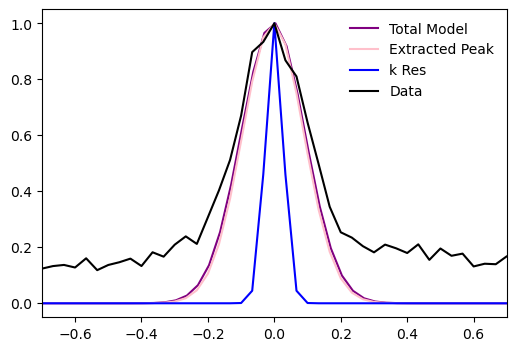

In [50]:
fig, ax = plt.subplots()
fig.set_size_inches(6,4)
#plt.gcf().set_dpi(300)
#ax = ax.flatten()

ky_slice_model = fitted_model.loc[{"kx": slice(.9,1.1)}].mean(dim="kx")
ky_slice_intr = intrinsic_fit.loc[{"kx": slice(.9,1.1)}].mean(dim="kx")
irf_k_test = mpes.gaussian(ax_ky.values, 1, 0, sigma_irf, 0)
data_slice = test_frame.loc[{"kx":slice(.9,1.1)}].mean(dim="kx")

ax.plot(fitted_model.ky.values-.03, ky_slice_model/np.max(ky_slice_model), color='purple', label = 'Total Model')
ax.plot(intrinsic_fit.ky.values, ky_slice_intr/np.max(ky_slice_intr), color='pink', label = 'Extracted Peak')
ax.plot(ax_ky.values, irf_k_test/np.max(irf_k_test), color='blue', label = 'k Res')
ax.plot(ax_ky.values, data_slice/np.max(data_slice), color='black', label = 'Data')
ax.legend(frameon=False)
ax.set_xlim(-.7,0.7)


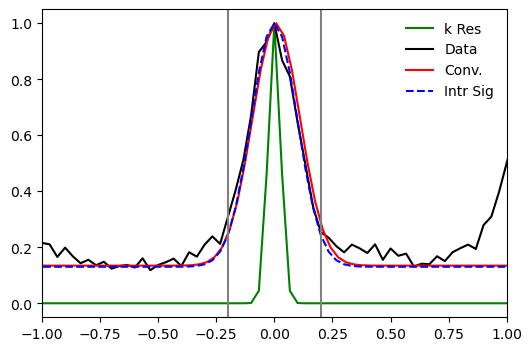

In [215]:
ky_slice_model = fitted_model.loc[{"kx": slice(.9,1.1)}].mean(dim="kx")
ky_slice_model = ky_slice_model / np.max(ky_slice_model)
ky_slice_intr = intrinsic_fit.loc[{"kx": slice(.9,1.1)}].mean(dim="kx")
ky_slice_intr = ky_slice_intr / np.max(ky_slice_intr)

irf_k_test = mpes.gaussian(ax_ky.values, 1, 0, sigma_irf, 0)
data_test = mpes.gaussian(ax_ky.values, 1, 0, .099, .15)

#irf_k_test /= np.trapz(irf_k_test, ax_ky.values)
decon_signal = fftconvolve(data_test, irf_k_test, mode='same')

fig, ax = plt.subplots()
fig.set_size_inches(6,4)
#plt.gcf().set_dpi(300)
#ax = ax.flatten()

ax.plot(ax_ky.values, irf_k_test/np.max(irf_k_test), color='green', label = 'k Res')
ax.plot(ax_ky.values, data_slice/np.max(data_slice), color='black', label = 'Data')

ax.plot(ax_ky.values-.025, decon_signal/np.max(decon_signal), color='red', label = 'Conv.')
ax.plot(ax_ky.values, data_test/np.max(data_test), color='blue', label = 'Intr Sig', linestyle = 'dashed')

ax.legend(frameon=False)
ax.set_xlim(-1, 1.)

ax.axvline(ylim[0], color = 'grey')
ax.axvline(ylim[1], color = 'grey')

#### Re-process FFT to Real Space Using Deonvolved Data


In [220]:
kspace_frame_fit = intrinsic_fit
kspace_frame_sym_fit, kspace_frame_win_fit, kspace_frame_sym_win_fit, kspace_window = mpes.window_MM(kspace_frame_fit, kx, ky, kx_int, ky_int, ax_kx, ax_ky, dkx, win_type, alpha, fwhm_kspace_res) # Window the MM

MM_frame_fit = kspace_frame_win_fit # Choose which kspace frame to FFT
r_axis, rspace_frame, x_cut, y_cut, x_rad_hwhm, y_rad_hwhm, x_brad, y_brad = mpes.FFT_MM(MM_frame_fit, zeropad, dkx, ax_kx, ax_ky) # Do the 2D FFT and extract real-space map and cuts

#### Testing RMS and Bohr Radius

In [221]:
# grid
N = 200
x = np.linspace(-50, 50, N)
y = np.linspace(-50, 50, N)
X, Y = np.meshgrid(x, y)

# anisotropic Gaussian
sigma_x, sigma_y = 10, 5
I = np.exp(-(X**2/(2*sigma_x**2) + Y**2/(2*sigma_y**2)))

# radius
R = np.sqrt(X**2 + Y**2)

# radial bins
r_bins = np.linspace(0, 50, 100)
r_centers = 0.5*(r_bins[:-1] + r_bins[1:])

radial = np.zeros(len(r_centers))

for i in range(len(r_centers)):
    mask = (R >= r_bins[i]) & (R < r_bins[i+1])
    radial[i] = I[mask].sum()

# optional: multiply by r (area weighting already partly included)
radial_r = radial * r_centers

In [224]:
I_MM = MM_frame_fit.where(MM_frame_fit >= 0)
X, Y = np.pi/a, np.pi/b

##############################

### Define real-space axis for FFT
k_step = dkx
zplength = zeropad #5*k_length+1
max_r = 1/(2*k_step)
r_axis = np.linspace(-max_r, max_r, num = zplength)
r_axis = 2*np.pi * np.fft.fftshift(np.fft.fftfreq(zplength, d=dkx)) #Include 2pi factor
r_axis = 0.1 * r_axis # Covnert to nm from Angstrom

### Do the FFT operations: |Psi(kx,ky)|^2 --> |Psi(x,y)|^2
I_MM = I_MM/np.max(I_MM) # |Psi(kx,ky)|^2
root_I_MM = np.sqrt(I_MM) # Psi(kx,ky)

fft_frame = np.fft.fft2(root_I_MM, [zplength, zplength])
fft_frame = np.fft.fftshift(fft_frame, axes = (0,1))
fft_frame = np.abs(fft_frame) # Psi(rx,ry)
psi_xy = xr.DataArray(fft_frame, coords = {"y": r_axis, "x": r_axis}) #Extracted intrinsic peak after deconv. k-space resolutation

I_xy = np.square((fft_frame))
I_xy = I_xy/np.max(I_xy) # Psi(rx,ry)|^2
I_xy = xr.DataArray(I_xy, coords = {"y": r_axis, "x": r_axis}) #Extracted intrinsic peak after deconv. k-space resolutation

### Take kx and ky cuts
kx_cut = I_MM.loc[{"ky":slice(0-.05,0+.05)}].mean(dim="ky")
ky_cut = I_MM.loc[{"kx":slice(X/2-.05,X/2+.05)}].mean(dim="kx")
kx_cut = kx_cut/np.max(kx_cut)
ky_cut = ky_cut/np.max(ky_cut)

### real space I_xy = Psi*^2 cuts along x and y
x_cut = I_xy.loc[{"y":slice(0)}].mean(dim='y')
y_cut = I_xy.loc[{"x":slice(0)}].mean(dim='x')
x_cut = x_cut/np.max(x_cut)
y_cut = y_cut/np.max(y_cut)

### From the Half-Width at Half-Max

x_brad = (np.abs(x_cut[int(zplength/2)-10:int(zplength/2)+200] - 0.5)).argmin()
x_brad = int(zplength/2)-10 + x_brad
x_brad = r_axis[x_brad]

y_brad = (np.abs(y_cut[int(zplength/2)-10:] - 0.5)).argmin()
y_brad = int(zplength/2)-10 + y_brad
y_brad = r_axis[y_brad]

### r-weighted distribution / 2D Radial Distribution ~ r*|Psi(r)|^2

x_rad_dist = np.abs(r_axis) * x_cut
y_rad_dist = np.abs(r_axis) * y_cut
x_rad_dist = x_rad_dist / np.max(x_rad_dist)
y_rad_dist = y_rad_dist / np.max(y_rad_dist)

x_brad = (x_rad_dist[int(zplength/2)-10:int(zplength/2)+100]).argmax().values
y_brad = (y_rad_dist[int(zplength/2)-10:int(zplength/2)+100]).argmax().values

x_brad = r_axis[int(zplength/2)-10 + x_brad]
y_brad = r_axis[int(zplength/2)-10 + y_brad]

RMS radius y: 0.49
hwhm y = 0.57
RMS radius x: 0.24
hwhm x = 0.30


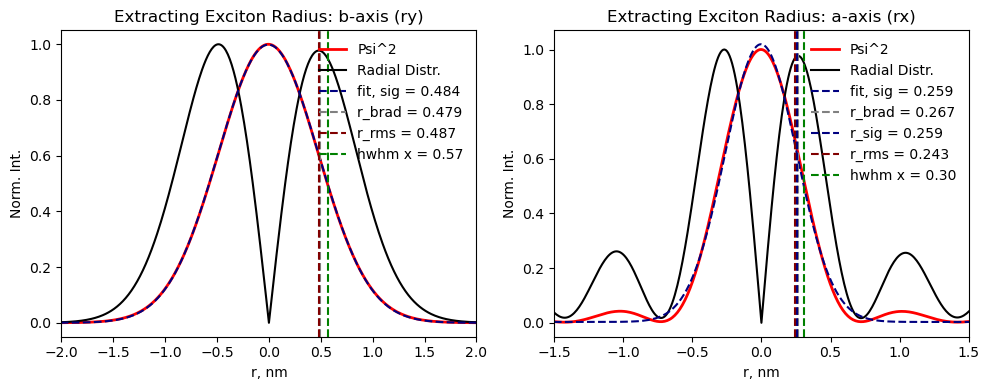

In [231]:
### Fit the Real-Space Distr. and Extract

# Fit r-y Cut
p0 = [1, 0, 0.2, 0]
bnds = ((0.5, -1, .05, 0), (1.2, 2, 5, 0.4))
popt_ry, pcov_r = curve_fit(mpes.gaussian, r_axis, y_cut, p0, method=None, bounds = bnds)
g_fit_ry = mpes.gaussian(r_axis, *popt_ry)
r_sig_fit_y = popt_ry[2]

cut_y = y_cut
dr = r_axis[1] - r_axis[0]
rms_y = np.sqrt(np.sum(r_axis**2 * cut_y * dr) / np.sum(cut_y * dr))

print(f"RMS radius y: {rms_y:.2f}")
print(f'hwhm y = {0.5*2.355*r_sig_fit_y:.2f}')

#Fit r-x Cut
p0 = [1, 0, 0.2, 0]
bnds = ((0.5, -1, .05, 0), (1.2, 2, 5, 0.4))
popt_rx, pcov_r = curve_fit(mpes.gaussian, r_axis, x_cut, p0, method=None, bounds = bnds)
g_fit_rx = mpes.gaussian(r_axis, *popt_rx)
r_sig_fit_x = popt_rx[2]

cut_x = x_cut

r1, r2 = np.abs(r_axis - -0.7).argmin(), np.abs(r_axis-0.7).argmin()
dr = r_axis[1] - r_axis[0]
rms_x = np.sqrt(np.sum(r_axis[r1:r2]**2 * cut_x[r1:r2] * dr) / np.sum(cut_x[r1:r2] * dr))
print(f"RMS radius x: {rms_x:.2f}")
print(f'hwhm x = {0.5*2.355*r_sig_fit_x:.2f}')

##################
### Plot Tests ###
##################
fig, ax = plt.subplots(1,2, sharey = False)
fig.set_size_inches(10,4)
ax = ax.flatten()

# First
#ax[0].plot(r_axis, psi_r_y, color = 'purple', label = 'Psi')
ax[0].plot(r_axis, y_cut, color = 'red', label = 'Psi^2', linewidth = 2)
ax[0].plot(r_axis, y_rad_dist, color = 'black', label = 'Radial Distr.')
ax[0].plot(r_axis, g_fit_ry, color = 'navy', label = f'fit, sig = {r_sig_fit_y:.3}', linestyle = 'dashed')

ax[0].axvline(rdist_brad_y, linestyle = 'dashed', color = 'grey', linewidth = 1.5, label = f'r_brad = {y_brad:.3}')
#ax[0].axvline(r_sig_fit_y, linestyle = 'dashed', color = 'navy', linewidth = 1.5, label = f'r_sig = {r_sig_fit_y:.3}')
ax[0].axvline(rms_y, linestyle = 'dashed', color = 'maroon', linewidth = 1.5, label = f'r_rms = {rms_y:.3}')
ax[0].axvline(0.5*2.355*r_sig_fit_y, linestyle = 'dashed', color = 'green', linewidth = 1.5, label = f'hwhm x = {0.5*2.355*r_sig_fit_y:.2f}')

ax[0].legend(frameon=False)

ax[0].set_xlim(-2,2)
ax[0].set_xlabel('r, nm')
ax[0].set_ylabel('Norm. Int.')
ax[0].set_title('Extracting Exciton Radius: b-axis (ry)')

# Second
#ax[1].plot(r_axis, psi_r_x, color = 'purple', label = 'Psi')
ax[1].plot(r_axis, x_cut, color = 'red', label = 'Psi^2', linewidth = 2)
ax[1].plot(r_axis, x_rad_dist, color = 'black', label = 'Radial Distr.')
ax[1].plot(r_axis, g_fit_rx, color = 'navy', label = f'fit, sig = {r_sig_fit_x:.3}', linestyle = 'dashed')

ax[1].axvline(rdist_brad_x, linestyle = 'dashed', color = 'grey', linewidth = 1.5, label = f'r_brad = {x_brad:.3}')
ax[1].axvline(r_sig_fit_x, linestyle = 'dashed', color = 'navy', linewidth = 1.5, label = f'r_sig = {r_sig_fit_x:.3}')
ax[1].axvline(rms_x, linestyle = 'dashed', color = 'maroon', linewidth = 1.5, label = f'r_rms = {rms_x:.3}')
ax[1].axvline(0.5*2.355*r_sig_fit_x, linestyle = 'dashed', color = 'green', linewidth = 1.5, label = f'hwhm x = {0.5*2.355*r_sig_fit_x:.2f}')

ax[1].legend(frameon=False)
ax[1].set_xlim(-1.5,1.5)
ax[1].set_xlabel('r, nm')
ax[1].set_ylabel('Norm. Int.')
ax[1].set_title('Extracting Exciton Radius: a-axis (rx)')

fig.tight_layout()

rms = 0.7038647039601994
1.224744871391589


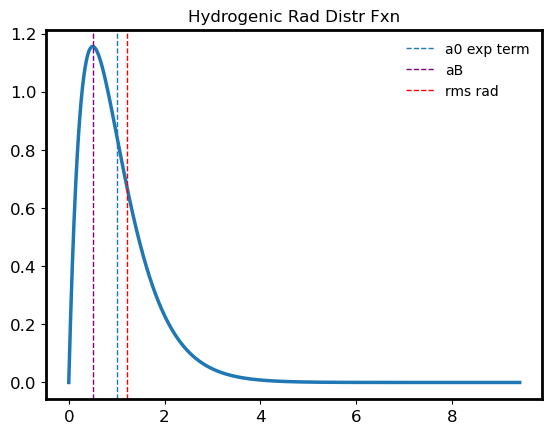

In [541]:
a0 = 1
psi = (np.exp(-r_axis[1024:]/a0))**2
R = 2*np.pi * r_axis[1024:] * psi

#plt.plot(r_axis[1024:], (np.exp(-r_axis[1024:]/a0))**2)
plt.plot(r_axis[1024:], R)

plt.axvline(a0, linestyle = 'dashed', linewidth = 1, label = 'a0 exp term')
plt.axvline(a0/2, linestyle = 'dashed', linewidth = 1, color = 'purple', label = 'aB')

#psi = (np.exp(-2*r_axis[1024:]/a0))

rms = np.sqrt(np.sum(r_axis[1024:]**2 * psi * dr) / np.sum(psi * dr))

print('rms = ' + str(rms))
print(np.sqrt(6)*a0*0.5)

#plt.axvline(rms, linestyle = 'dashed', linewidth = 1, color = 'red')
plt.axvline(np.sqrt(6)*a0*0.5, linestyle = 'dashed', linewidth = 1, color = 'red', label = 'rms rad')

plt.title('Hydrogenic Rad Distr Fxn')
plt.legend(frameon=False)

#### Plot Results of Deconvolution


C:\Users\lloyd\AppData\Local\Temp\ipykernel_22280\2975988587.py:135: UserWarning: This figure includes Axes that are not compatible with tight_layout, so results might be incorrect.
  fig.tight_layout()


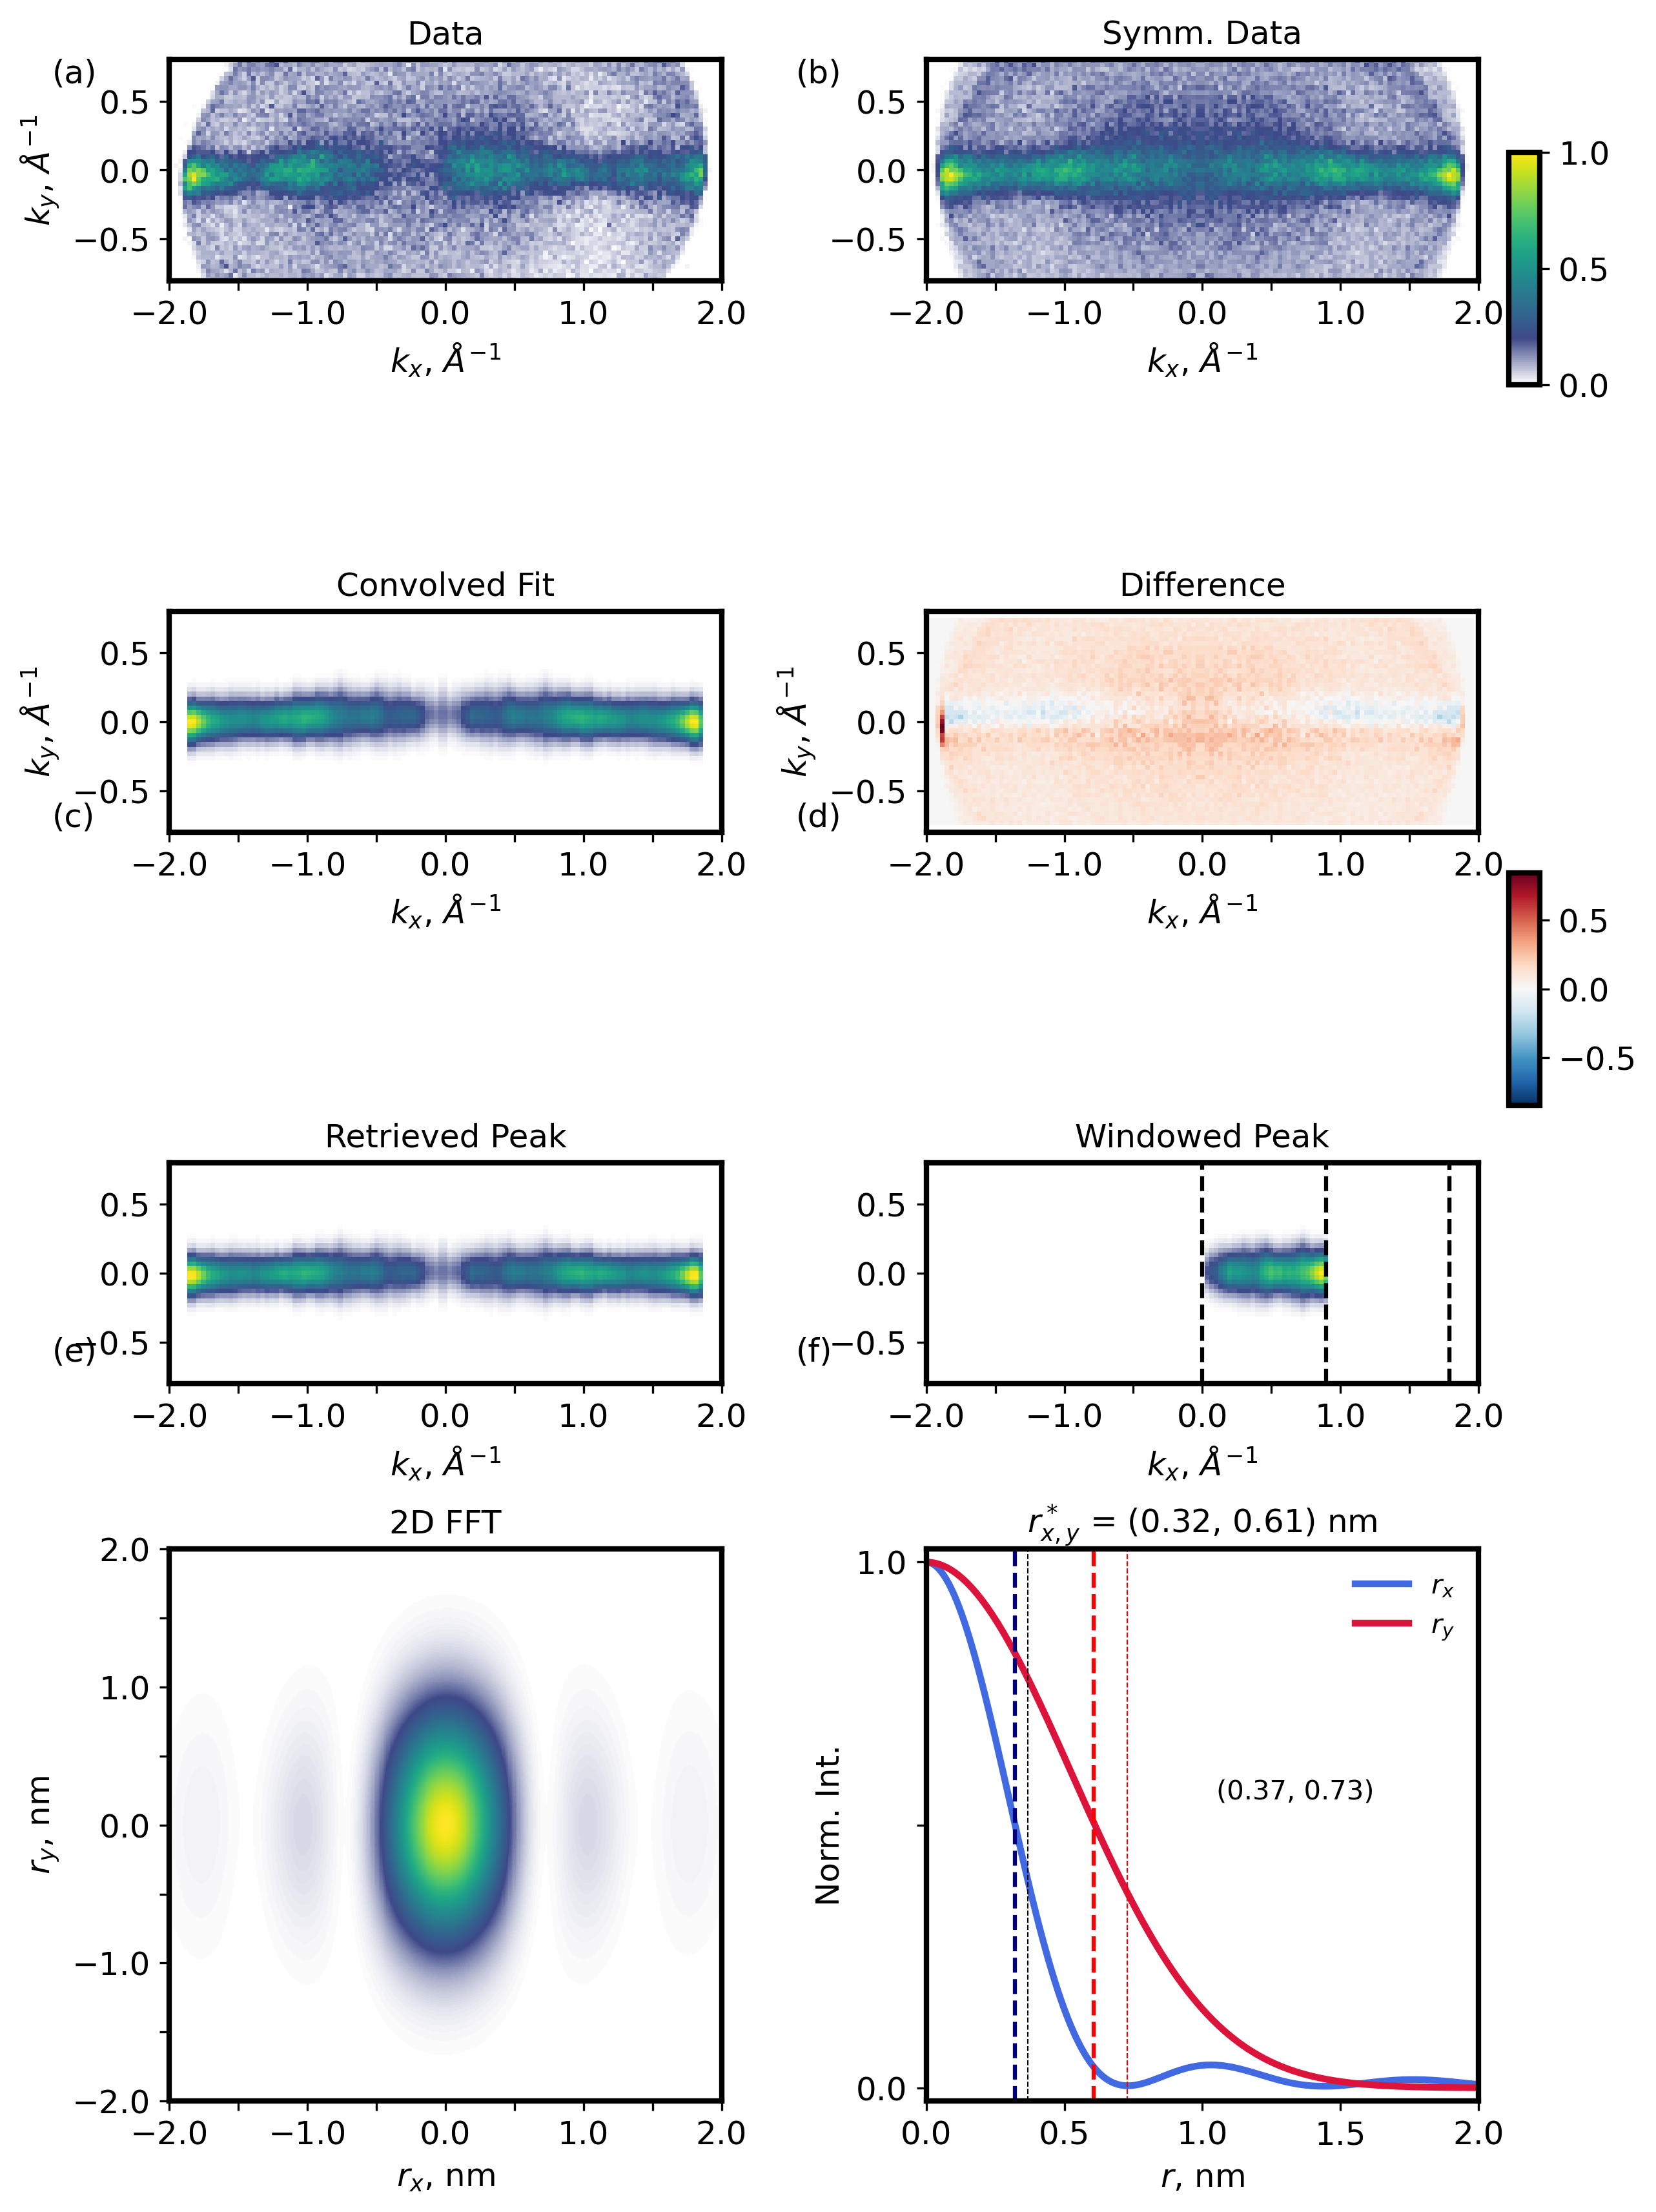

In [280]:
save_figure = False
figure_file_name = 'deconvolve_RT' 
image_format = 'svg'
hfont = {'fontname':'Helvetica'}

fit_difference = test_frame/np.max(test_frame) - fitted_model/np.max(fitted_model)
fit_difference = fit_difference.loc[{"ky":slice(-.75,.75)}]
difference_scale = np.max(np.abs(fit_difference))
#fit_difference = fit_difference/np.max(np.abs(fit_difference.loc[{"kx":slice(-1.8,2*X)}]))

fig, ax = plt.subplots(4,2, sharey = False)
fig.set_size_inches(8, 12)
plt.gcf().set_dpi(300)
ax = ax.flatten()

extent = [ax_kx[0],ax_kx[-1],ax_ky[0],ax_ky[-1]]

im0 = ax[0].imshow(kspace_frame, cmap = cmap_LTL, origin = 'lower', extent = extent)
im1 = ax[1].imshow(test_frame, cmap = cmap_LTL, origin = 'lower', extent = extent)
#ax[0].imshow(fit_difference, vmin = -1, vmax = 1, cmap = 'seismic_r', origin = 'lower', extent = [-2,2,-2,2])
im2 = ax[2].imshow(fitted_model, cmap = cmap_LTL, vmin=0, vmax = 1, origin = 'lower', extent = extent)
#ax[2].imshow(intrinsic_fit.T, cmap = cmap_LTL, origin = 'lower', extent = [-2,2,-2,2])
im3 = ax[3].imshow(fit_difference, vmin = -1*difference_scale, vmax = 1*difference_scale, cmap = 'RdBu_r', origin = 'lower', extent = [ax_kx[0],ax_kx[-1],-0.75,0.75])
im4 = ax[4].imshow(intrinsic_fit, cmap = cmap_LTL, origin = 'lower', extent = extent)
im5 = ax[5].imshow(kspace_frame_win_fit, cmap = cmap_LTL, origin = 'lower', extent = extent)

fs = 12
ax[0].set_title('Data', fontsize = fs)
ax[1].set_title('Symm. Data', fontsize = fs)
ax[2].set_title('Convolved Fit', fontsize = fs)
ax[3].set_title('Difference', fontsize = fs)
ax[4].set_title('Retrieved Peak', fontsize = fs)
ax[5].set_title('Windowed Peak', fontsize = fs)

ax[0].set_ylabel('$k_y$, $\AA^{-1}$', fontsize = fs)
ax[2].set_ylabel('$k_y$, $\AA^{-1}$', fontsize = fs)
ax[3].set_ylabel('$k_y$, $\AA^{-1}$', fontsize = fs)

for a in [0, 1, 2, 3, 4, 5]:
    
    ax[a].set_xlabel('$k_x$, $\AA^{-1}$', fontsize = fs)
    ax[a].set_ylim(-0.8,0.8)
    ax[a].set_aspect(1)
    ax[a].set_xticks(np.arange(-2,2.2,.5))
    for label in ax[a].xaxis.get_ticklabels()[1::2]:
        label.set_visible(False)
   # label.set_xticklabels(tick_labels.astype(int))

ax[5].axvline(0, linestyle='dashed',color='black', linewidth = 1.5)
ax[5].axvline(X, linestyle='dashed',color='black', linewidth = 1.5)
ax[5].axvline(2*X, linestyle='dashed',color='black', linewidth = 1.5)
ax[5].axvline(2*X, linestyle='dashed',color='black', linewidth = 1.5)

#ax[1].set_ylabel('$k_y$, $\AA^{-1}$', fontsize = 14)
#ax[2].set_ylabel('$k_y$, $\AA^{-1}$', fontsize = 14)

# add space for colour bar
fig.subplots_adjust(right=0.5)
cbar_ax = fig.add_axes([.98, 0.77, 0.02, 0.1])
fig.colorbar(im2, cax=cbar_ax)

fig.subplots_adjust(right=0.5)
cbar_ax = fig.add_axes([.98, 0.46, 0.02, 0.1])
fig.colorbar(im3, cax=cbar_ax)

fs = 12
fig.text(.04, 0.9, "(a)", fontsize = fs, fontweight = 'regular')
fig.text(.52, 0.9, "(b)", fontsize = fs, fontweight = 'regular')
fig.text(.04, 0.58, "(c)", fontsize = fs, fontweight = 'regular')
fig.text(.52, 0.58, "(d)", fontsize = fs, fontweight = 'regular')
fig.text(.04, 0.35, "(e)", fontsize = fs, fontweight = 'regular')
fig.text(.52, 0.35, "(f)", fontsize = fs, fontweight = 'regular')

im0 = ax[6].imshow(rspace_frame/np.max(rspace_frame), clim = None, origin='lower', vmax = 1, cmap=cmap_LTL, interpolation='none', extent = [r_axis[0], r_axis[-1], r_axis[0], r_axis[-1]]) #kx, ky, t
#single_k_circle = plt.Circle((single_ky, single_kx), single_rad, color='red', linestyle = 'dashed', linewidth = 1.5, clip_on=False, fill=False)
#ax[1].add_patch(single_k_circle)
ax[6].set_aspect(1)
ax[7].set_aspect(1)

ax[6].set_xticks(np.arange(-2,2.2,.5))
for label in ax[6].xaxis.get_ticklabels()[1::2]:
    label.set_visible(False)
   # label.set_xticklabels(tick_labels.astype(int))
    
ax[6].set_yticks(np.arange(-2,2.2,.5))
for label in ax[6].yaxis.get_ticklabels()[1::2]:
    label.set_visible(False)

ax[7].set_xticks(np.arange(-2,2.2,.5))
for label in ax[7].xaxis.get_ticklabels()[1::2]:
    label.set_visible(True)
   # label.set_xticklabels(tick_labels.astype(int))
    
ax[7].set_yticks(np.arange(-2,2.1,.5))
for label in ax[7].yaxis.get_ticklabels()[1::2]:
    label.set_visible(False)

ax[6].set_xlim(-2,2)
ax[6].set_ylim(-2,2)
#ax[0].set_box_aspect(1)
ax[6].set_xlabel('$r_x$, nm', fontsize = fs)
ax[6].set_ylabel('$r_y$, nm', fontsize = fs)
ax[6].tick_params(axis='both', labelsize=fs)
ax[6].set_title('2D FFT', fontsize = fs)

#ax[2].plot(r_axis, x_cut/np.max(1), color = 'black', label = '$r_b$')
ax[7].plot(r_axis, x_cut/np.max(x_cut), color = 'royalblue', label = '$r_x$')
#ax[3].plot(r_axis, r2_cut_x, color = 'black', linestyle = 'dashed')
ax[7].plot(r_axis, y_cut/np.max(y_cut), color = 'crimson', label = '$r_y$')
#ax[3].plot(r_axis, r2_cut_y, color = 'red', linestyle = 'dashed')

ax[7].axvline(x_brad, linestyle = 'dashed', color = 'navy', linewidth = 1.5)
ax[7].axvline(y_brad, linestyle = 'dashed', color = 'red', linewidth = 1.5)
ax[7].axvline(rdist_brad_x, linestyle = 'dashed', color = 'black', linewidth = .5)
ax[7].axvline(rdist_brad_y, linestyle = 'dashed', color = 'red', linewidth = .5)

ax[7].set_xlabel('$r$, nm', fontsize = fs)
ax[7].set_ylabel('Norm. Int.', fontsize = fs)
ax[7].set_title(f"$r^*_{{x,y}}$ = ({round(x_brad,2)}, {round(y_brad,2)}) nm", fontsize = fs)
ax[7].tick_params(axis='both', labelsize=fs)
ax[7].set_yticks(np.arange(-0,1.5,0.5))
ax[7].set_xlim([0, 2])
ax[7].set_ylim([-0.025, 1.025])
ax[7].set_aspect(2/(1.025+0.025))
ax[7].set_xlabel('$r$, nm', fontsize = fs)
ax[7].legend(frameon=False, fontsize = fs-2)
ax[7].text(1.05, 0.55,  f"({np.round(rdist_brad_x,2)}, {np.round(rdist_brad_y,2)})", size=fs-2)

new_rc_params = {'text.usetex': False, "svg.fonttype": 'none', "font.family":'helvetica'}
params = {'lines.linewidth' : 2.5, 'axes.linewidth' : 2, 'axes.labelsize' : 12, 
              'xtick.labelsize' : 12, 'ytick.labelsize' : fs, 'axes.titlesize' : fs, 'legend.fontsize' : 10}
plt.rcParams.update(params)
plt.rcParams.update(new_rc_params)

fig.tight_layout()

if save_figure is True:
    fig.savefig(figure_file_name + '.'+ image_format, bbox_inches='tight', format=image_format)

#### Plot Raw, Symm., and Windowed MMs

C:\Users\lloyd\AppData\Local\Temp\ipykernel_22280\183525624.py:51: UserWarning: This figure includes Axes that are not compatible with tight_layout, so results might be incorrect.
  fig.tight_layout()
findfont: Font family ['helvetica'] not found. Falling back to DejaVu Sans.


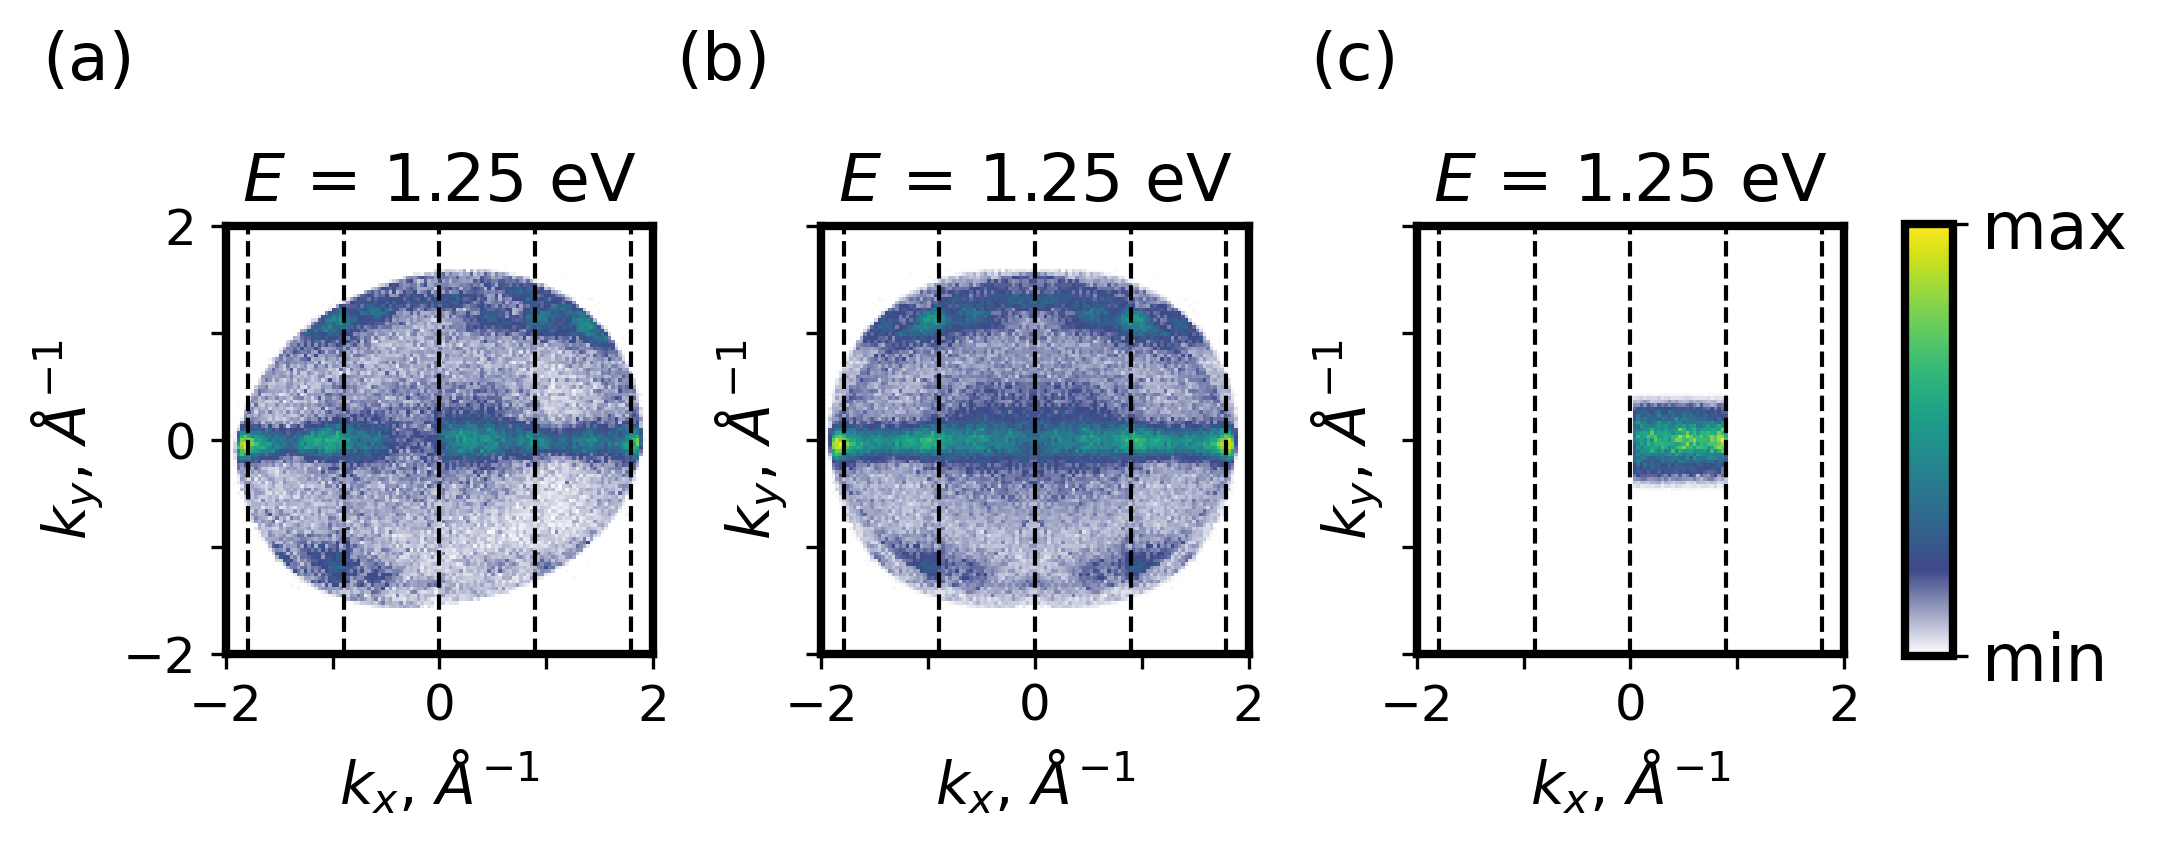

In [27]:
save_figure = False
figure_file_name = '2DFFT_Windowing' 

fig, ax = plt.subplots(1, 3, sharey=True)
plt.gcf().set_dpi(300)
ax = ax.flatten()

im0 = ax[0].imshow(kspace_frame/kspace_frame.max(), origin='lower', vmax = 1, cmap=cmap_LTL, extent = [ax_kx[0],ax_kx[-1],ax_ky[0],ax_ky[-1]])
im1 = ax[1].imshow(kspace_frame_sym/kspace_frame_sym.max(), origin='lower', vmax = 1, cmap=cmap_LTL, extent = [ax_kx[0],ax_kx[-1],ax_ky[0],ax_ky[-1]])
im2 = ax[2].imshow(kspace_frame_sym_win/kspace_frame_sym_win.max(), origin='lower', vmax = 1, cmap=cmap_LTL, extent = [ax_kx[0],ax_kx[-1],ax_ky[0],ax_ky[-1]])

for i in np.arange(3):
    #ax[i].axhline(0, color='black', linewidth = 1, linestyle = 'dashed')
    ax[i].axvline(0, color='black', linewidth = 1, linestyle = 'dashed')
    ax[i].axvline(-X, color='black', linewidth = 1, linestyle = 'dashed')
    ax[i].axvline(X, color='black', linewidth = 1, linestyle = 'dashed')
    ax[i].axvline(2*X, color='black', linewidth = 1, linestyle = 'dashed')
    ax[i].axvline(-2*X, color='black', linewidth = 1, linestyle = 'dashed')
    
    ax[i].set_aspect(1)
    #ax[0].axhline(y,color='black')
    #ax[0].axvline(x,color='black')
    
    ax[i].set_xticks(np.arange(-2,2.2,1))
    for label in ax[i].xaxis.get_ticklabels()[1::2]:
        label.set_visible(False)
        
    ax[i].set_yticks(np.arange(-2,2.1,1))
    for label in ax[i].yaxis.get_ticklabels()[1::2]:
        label.set_visible(False)
    
    ax[i].set_xlim(-2,2)
    ax[i].set_ylim(-2,2)
    #ax[0].set_box_aspect(1)

    ax[i].set_xlabel('$k_x$, $\AA^{-1}$', fontsize = 14)
    ax[i].set_ylabel('$k_y$, $\AA^{-1}$', fontsize = 14)
    ax[i].tick_params(axis='both', labelsize=12)
    ax[i].set_title('$E$ = ' + str(E) + ' eV', fontsize = 16)

fig.text(.03, 0.75, "(a)", fontsize = 16, fontweight = 'regular')
fig.text(.36, 0.75, "(b)", fontsize = 16, fontweight = 'regular')
fig.text(.69, 0.75, "(c)", fontsize = 16, fontweight = 'regular')

fig.subplots_adjust(right=0.8)
cbar_ax = fig.add_axes([1, 0.35, 0.025, 0.3])
fig.colorbar(im2, cax=cbar_ax, ticks = [0,1])
cbar_ax.set_yticklabels(['min', 'max'], fontsize=16)  # vertically oriented colorbar

#fig.colorbar(im, fraction=0.046, pad=0.04)
fig.tight_layout()
plt.show()

if save_figure is True:
    fig.savefig((figure_file_name +'.svg'), format='svg')

#### Plot 2D FFT and Line Cuts

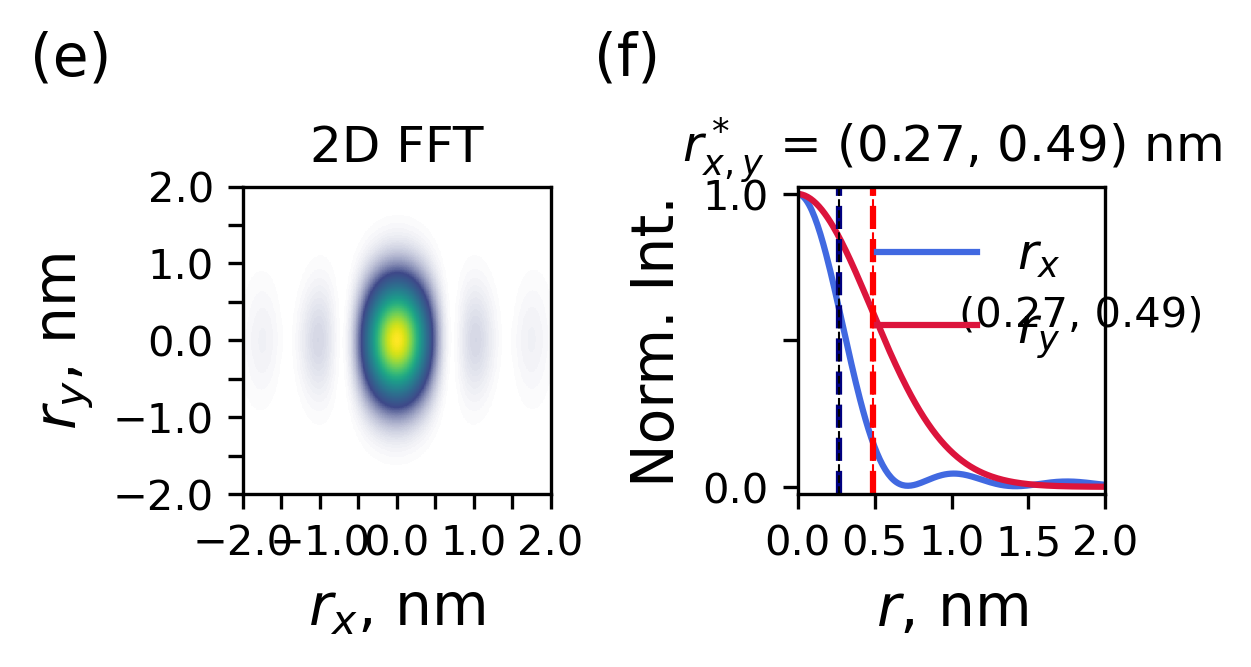

In [209]:
### PLOT ###

save_figure = False
figure_file_name = 'MM_FFT_120k_deconv' 
image_format = 'svg'

fig, ax = plt.subplots(1, 2)
fig.set_size_inches(4,3)
plt.gcf().set_dpi(300)
ax = ax.flatten()

im0 = ax[0].imshow(rspace_frame/np.max(rspace_frame), clim = None, origin='lower', vmax = 1, cmap=cmap_LTL, interpolation='none', extent = [r_axis[0], r_axis[-1], r_axis[0], r_axis[-1]]) #kx, ky, t
#single_k_circle = plt.Circle((single_ky, single_kx), single_rad, color='red', linestyle = 'dashed', linewidth = 1.5, clip_on=False, fill=False)
#ax[1].add_patch(single_k_circle)
ax[0].set_aspect(1)
ax[1].set_aspect(1)

#ax[0].axhline(y,color='black')
#ax[0].axvline(x,color='bl ack')

ax[0].set_xticks(np.arange(-2,2.2,.5))
for label in ax[0].xaxis.get_ticklabels()[1::2]:
    label.set_visible(False)
   # label.set_xticklabels(tick_labels.astype(int))
    
ax[0].set_yticks(np.arange(-2,2.2,.5))
for label in ax[0].yaxis.get_ticklabels()[1::2]:
    label.set_visible(False)

ax[1].set_xticks(np.arange(-2,2.2,.5))
for label in ax[1].xaxis.get_ticklabels()[1::2]:
    label.set_visible(True)
   # label.set_xticklabels(tick_labels.astype(int))
    
ax[1].set_yticks(np.arange(-2,2.1,.5))
for label in ax[1].yaxis.get_ticklabels()[1::2]:
    label.set_visible(False)

ax[0].set_xlim(-2,2)
ax[0].set_ylim(-2,2)
#ax[0].set_box_aspect(1)
ax[0].set_xlabel('$r_x$, nm', fontsize = 14)
ax[0].set_ylabel('$r_y$, nm', fontsize = 14)
ax[0].tick_params(axis='both', labelsize=10)
ax[0].set_title('2D FFT', fontsize = 12)

#ax[2].plot(r_axis, x_cut/np.max(1), color = 'black', label = '$r_b$')
ax[1].plot(r_axis, x_cut/np.max(x_cut), color = 'royalblue', label = '$r_x$')
#ax[3].plot(r_axis, r2_cut_x, color = 'black', linestyle = 'dashed')
ax[1].plot(r_axis, y_cut/np.max(y_cut), color = 'crimson', label = '$r_y$')
#ax[3].plot(r_axis, r2_cut_y, color = 'red', linestyle = 'dashed')

ax[1].axvline(x_brad, linestyle = 'dashed', color = 'navy', linewidth = 1.5)
ax[1].axvline(y_brad, linestyle = 'dashed', color = 'red', linewidth = 1.5)
ax[1].axvline(rdist_brad_x, linestyle = 'dashed', color = 'black', linewidth = .5)
ax[1].axvline(rdist_brad_y, linestyle = 'dashed', color = 'red', linewidth = .5)

ax[1].set_ylim([-0.025, 1.025])
ax[1].set_xlabel('$r$, nm', fontsize = 14)
ax[1].set_ylabel('Norm. Int.', fontsize = 14)
ax[1].set_title(f"$r^*_{{x,y}}$ = ({round(x_brad,2)}, {round(y_brad,2)}) nm", fontsize = 12)
ax[1].tick_params(axis='both', labelsize=10)
ax[1].set_yticks(np.arange(-0,1.5,0.5))
ax[1].set_xlim([0, 2])
ax[1].set_aspect(2/(1.025+0.025))
ax[1].set_xlabel('$r$, nm')
ax[1].legend(frameon=False, fontsize = 12)
ax[1].text(1.05, 0.55,  f"({np.round(rdist_brad_x,2)}, {np.round(rdist_brad_y,2)})", size=10)

#fig.subplots_adjust(right=0.58, top = 1.1)
fig.tight_layout()
new_rc_params = {'text.usetex': False, "svg.fonttype": 'none'}
plt.rcParams.update(new_rc_params)

fig.text(.03, 0.8, "(e)", fontsize = 14, fontweight = 'regular')
fig.text(0.5, 0.8, "(f)", fontsize = 14, fontweight = 'regular')

if save_figure is True:
    fig.savefig(figure_file_name + '.'+ image_format, bbox_inches='tight', format=image_format)
    
#print("x: " + str(round(rdist_brad_x,3)))
#print("y: " + str(round(rdist_brad_y,3)))

#### TESTING: Do line fits analysis to cross check values

In [210]:
# Generate 2D Gaussian Test Case

sigma = 0.105
kx_grid, ky_grid = np.meshgrid(ax_kx, ax_ky)
kspace_test = np.exp(-(kx_grid**2 + ky_grid**2) / (2 * sigma**2))

kspace_test = xr.DataArray(
    kspace_test,
    coords={"ky": ax_ky, "kx": ax_kx},
    dims=["ky", "kx"]
)

kspace_test_psi = np.sqrt(kspace_test)

### FFT
k_step = dkx
zplength = zeropad

# Use np to define
r_axis = np.linspace(-max_r, max_r, num = zplength)
r_axis = 2*np.pi * np.fft.fftshift(np.fft.fftfreq(zplength, d=dkx)) #Include 2pi factor
r_axis = 0.1 * r_axis # Covnert to nm from Angstrom

rspace_test_psi = np.fft.fft2(kspace_test_psi, [zplength, zplength])
rspace_test_psi = np.fft.fftshift(rspace_test_psi, axes = (0,1))
rspace_test_I = np.square(np.abs(rspace_test_psi)) #frame squared
rspace_test_psi = rspace_test_psi / np.max(np.abs(rspace_test_psi))

rspace_test_I = rspace_test_I / np.max(rspace_test_I)

rcut_psix = rspace_test_psi[:, int(len(rspace_test_psi[0])/2)]
rcut_Ix = rspace_test_I[:, int(len(rspace_test_I[0])/2)]

rspace_radial_distr = np.square(np.abs(rcut_psix)) * np.abs(r_axis)
rspace_radial_distr = rspace_radial_distr / np.max(rspace_radial_distr)

rspace_radial_distr_2 = np.square(np.abs(rcut_psix) * np.abs(r_axis) )
rspace_radial_distr_2 = rspace_radial_distr_2 / np.max(rspace_radial_distr_2)

# Fit rx Cut
p0 = [0.5, 0.9, 0.5, 0.0]
popt_rx_test, pcov = curve_fit(mpes.gaussian, r_axis, rcut_Ix, p0, method=None, bounds = bnds)
r_fit_test = mpes.gaussian(r_axis, *popt_rx_test)
r_fit_test_sigma = popt_rx_test[2]
#plt.plot(ax_kx, kx_cut) ; plt.plot(ax_kx, g_fit_kx)

rms = np.sqrt(sum(r_axis**2 * rcut_Ix) / sum(rcut_Ix))
hwhm = np.abs(r_fit_test - 0.5).argmin()


pred. from k sig = 0.476
x RMS = 0.476
Gaussian sigma = 0.476
hwhm = 0.561
radial RMS = 0.673


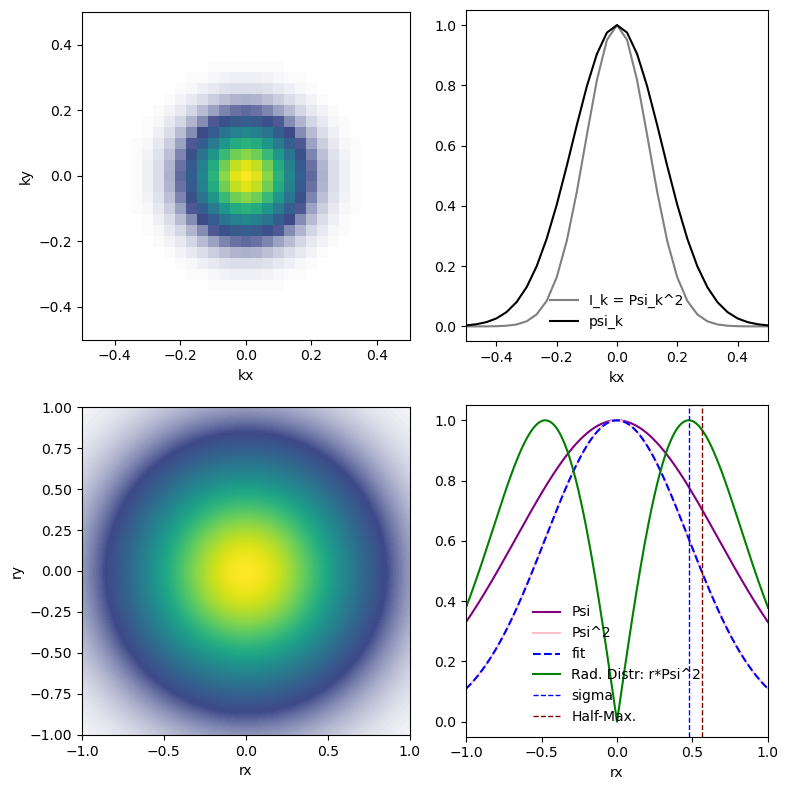

In [213]:
fig, ax = plt.subplots(2, 2, sharey=False)
fig.set_size_inches(8, 8, forward=False)
ax = ax.flatten()

kspace_test.plot.imshow(ax=ax[0], add_colorbar=False, cmap=cmap_LTL)

kspace_test.loc[{"ky":slice(-0.025,0.025)}].mean(dim='ky').plot(ax=ax[1], color='grey', label = 'I_k = Psi_k^2')
kspace_test_psi.loc[{"ky":slice(-0.025,0.025)}].mean(dim='ky').plot(ax=ax[1], color = 'black', label = 'psi_k')

ax[0].set_aspect(1)
ax[0].set_xlim(-.5,0.5)
ax[0].set_ylim(-.5,0.5)

ax[1].set_aspect(1)
ax[1].set_xlim(-.5,0.5)

extent = [ r_axis[0], r_axis[-1], r_axis[0], r_axis[-1] ]
ax[2].imshow(rspace_test_I, cmap=cmap_LTL, extent = extent)
ax[3].plot(r_axis, np.abs(rcut_psix), color = 'purple', label = 'Psi')
ax[3].plot(r_axis, rcut_Ix, color = 'pink', label = 'Psi^2')

ax[3].plot(r_axis, r_fit_test, linestyle = 'dashed', color = 'blue', label='fit')
ax[3].plot(r_axis, rspace_radial_distr, color = 'green', label = 'Rad. Distr: r*Psi^2')

ax[3].axvline(r_fit_test_sigma, linestyle = 'dashed', color = 'blue', label='sigma', linewidth = 1)
#ax[3].plot(r_axis, rspace_radial_distr_2)
#ax[3].axvline(r_fit_test_sigma*np.sqrt(2), linestyle = 'dashed')
ax[3].axvline(np.abs(r_axis[hwhm]), linestyle = 'dashed', color = 'maroon', label = 'Half-Max.', linewidth = 1)
#ax[3].axhline(.6, linestyle = 'dashed')
#kspace_test.loc[{"ky":slice(-0.025,0.025)}].mean(dim='ky').plot(ax=ax[1], color='grey')
#kspace_test_psi.loc[{"ky":slice(-0.025,0.025)}].mean(dim='ky').plot(ax=ax[1], color = 'black')

ax[2].set_xlabel('rx')
ax[2].set_ylabel('ry')
ax[3].set_xlabel('rx')

ax[2].set_xlim(-1, 1)
ax[2].set_ylim(-1, 1)
ax[3].set_xlim(-1, 1)
ax[2].set_aspect(1)
ax[3].set_aspect(2)
ax[1].legend(frameon=False)
ax[3].legend(frameon=False)

fig.tight_layout()

print(f'pred. from k sig = {0.1 * 1/(2*sigma):.3f}')
print(f'x RMS = {rms:.3f}')
print(f'Gaussian sigma = {r_fit_test_sigma:.3f}')
print(f'hwhm = {np.abs(r_axis[hwhm]):.3f}')

print(f'radial RMS = {r_fit_test_sigma*np.sqrt(2):.3f}')


Pred. Rx (rad) from Fit of k Peak (0.5 A^-1): 0.141 nm
Rx (rad) from Fit of Real-space After FFT: 0.366 nm

Pred. Ry (rad) from Fit of k Peak (0.1096 A^-1): 0.645 nm
Ry (rad) from Fit of Real-space After FFT: 0.688 nm
Ry (rad) from Fit of Real-space After FFT of k-fit: 0.645 nm
Ry (r^2 Bohr Rad) from Fit of Real-space After FFT of k-fit: 0.644 nm


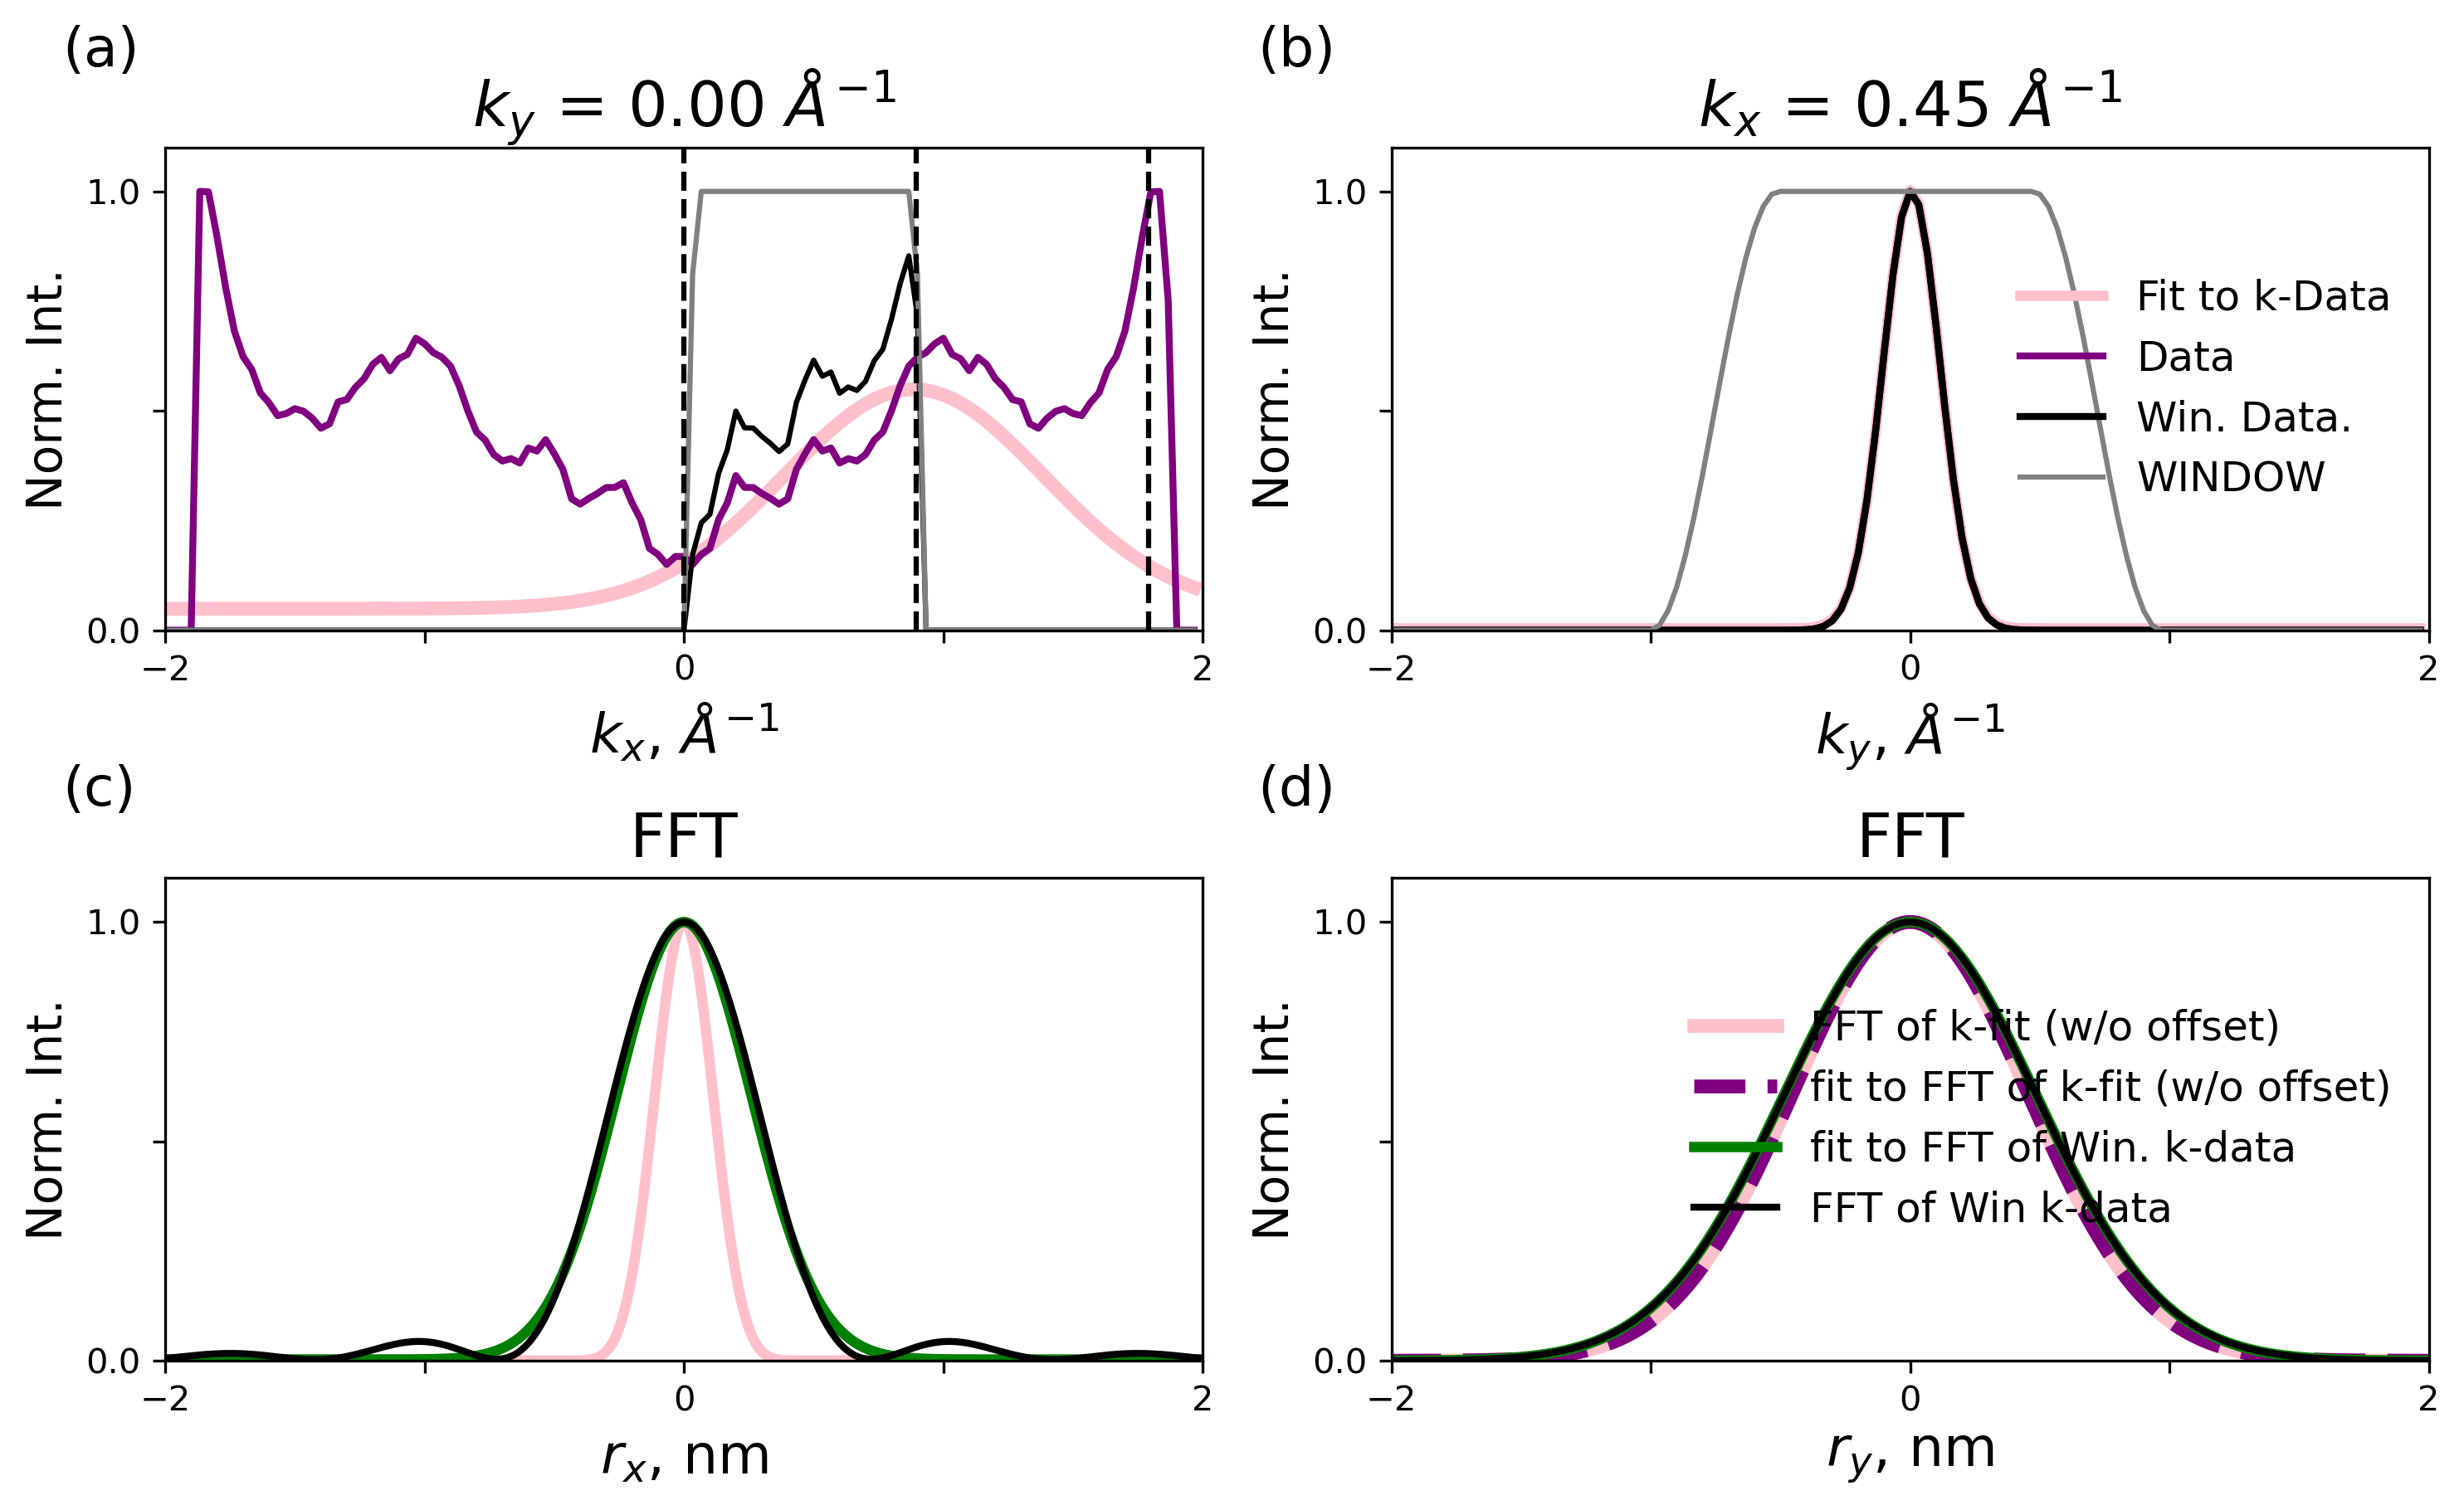

In [70]:
test_frame = kspace_frame_sym
test_frame_win = kspace_frame_sym_win

test_frame = kspace_frame_fit
test_frame_win = kspace_frame_win_fit

kx = X/2
kx_cut = test_frame.loc[{"ky":slice(-0.05,0.05)}].mean(dim="ky")
ky_cut = test_frame.loc[{"kx":slice(kx-.05,kx+.05)}].mean(dim="kx")
kx_win_cut = test_frame_win.loc[{"ky":slice(-0.05,0.05)}].mean(dim="ky")
ky_win_cut = test_frame_win.loc[{"kx":slice(kx-.05,kx+.05)}].mean(dim="kx")
window_kx_cut = kspace_window.loc[{"ky":slice(-0.05,0.05)}].mean(dim="ky")
window_ky_cut = kspace_window.loc[{"kx":slice(kx-.05,kx+.05)}].mean(dim="kx")
    
#kx_win_cut = MM_frame.loc[{"ky":slice(-.25,.25)}].sum(dim="ky")
#ky_win_cut = MM_frame.loc[{"kx":slice(-.05,1.1)}].sum(dim="kx")

#ky_cut = MM_frame[:,int(len(MM_frame[0])/2)-1-4:int(len(MM_frame[0])/2)-1+4].sum(axis=1)
#kx_cut = MM_frame[int(len(MM_frame[0])/2)-1-4:int(len(MM_frame[0])/2)-1+4,:].sum(axis=0)

ky_cut = ky_cut/np.max(ky_cut)
kx_cut = kx_cut/np.max(kx_cut)

kx_win_cut = kx_win_cut/np.max(kx_cut.loc[{"kx":slice(0,1.5)}])
ky_win_cut = ky_win_cut/np.max(ky_win_cut)

# Fit kx Cut
xlim = [-0.1, 1]
p0 = [0.5, 0.9, 0.5, 0.0]
bnds = ((0.1, -0.5, .2, 0), (1.5, 1.5, 1.2, 0.8))
popt_kx, pcov = curve_fit(mpes.gaussian, ax_kx.loc[{"kx":slice(xlim[0],xlim[1])}], kx_cut.loc[{"kx":slice(xlim[0],xlim[1])}], p0, method=None, bounds = bnds)
g_fit_kx = mpes.gaussian(ax_kx, *popt_kx)
k_sig_fit_x = popt_kx[2]
#plt.plot(ax_kx, kx_cut) ; plt.plot(ax_kx, g_fit_kx)

# Fit ky Cut
ylim = [-.2, .2]
p0 = [1, 0.0, .105, 0.0]
bnds = ((0.5, -0.2, 0, 0), (1.5, 0.2, .2, .5)) #Amp, mean, std. offset
popt_ky, pcov = curve_fit(mpes.gaussian, ax_ky.loc[{"ky":slice(ylim[0],ylim[1])}], ky_cut.loc[{"ky":slice(ylim[0],ylim[1])}], p0, method=None, bounds = bnds)
g_fit_ky = mpes.gaussian(ax_ky, *popt_ky)

#initial_guess = (.1, .05, 1, 0)
#popt_ky = fit_convolved_model(ax_ky.loc[{"ky":slice(ylim[0],ylim[1])}], ky_cut.loc[{"ky":slice(ylim[0],ylim[1])}], sigma_irf, initial_guess)
# Retrieve fit components
#g_fit_ky = lorentzian_(ax_kx.values, *popt_ky)
#fitted_model = convolved_model(ax_kx.values, *popt, sigma_irf)
#popt_ky, pcov = curve_fit(lorentzian, ax_ky.loc[{"ky":slice(ylim[0],ylim[1])}], ky_cut.loc[{"ky":slice(ylim[0],ylim[1])}], p0, method=None, bounds = bnds)
#popt_ky = [0.88, 0.0, .3, 0.12]
#g_fit_ky = lorentzian(ax_ky, *popt_ky)

k_sig_fit_y = popt_ky[2]
#plt.plot(ax_ky, ky_cut) ; plt.plot(ax_ky, g_fit_ky)

#Fit r-x Cut
p0 = [1, 0, 0.2, 0]
bnds = ((0.5, -1, .05, 0), (1.2, 2, 5, 0.4))
popt_rx, pcov_r = curve_fit(mpes.gaussian, r_axis, x_cut/np.max(x_cut), p0, method=None, bounds = bnds)
g_fit_rx = mpes.gaussian(r_axis, *popt_rx)
r_sig_fit_x = popt_rx[2]

#Fit r-y Cut
p0 = [1, 0, 0.2, 0]
bnds = ((0.5, -1, .05, 0), (1.2, 2, 5, 0.4))
popt_ry, pcov_r = curve_fit(mpes.gaussian, r_axis, y_cut/np.max(y_cut), p0, method=None, bounds = bnds)
g_fit_ry = mpes.gaussian(r_axis, *popt_ry)
r_sig_fit_y = popt_ry[2]

# Do the FFT of the fit in the k-space to get verify r-space
g_fit_fft = np.abs(np.fft.fftshift(np.fft.fft((g_fit_kx-popt_kx[3])**0.5, zeropad)))  # Compute FFT
g_fit_fft_x_root = g_fit_fft / np.max(g_fit_fft)
g_fit_fft_x = g_fit_fft_x_root**2

g_fit_fft = np.abs(np.fft.fftshift(np.fft.fft((g_fit_ky-popt_ky[3])**0.5, zeropad)))  # Compute FFT
g_fit_fft_y_root = g_fit_fft / np.max(np.abs(g_fit_fft))
g_fit_fft_y = g_fit_fft_y_root**2
g_fit_fft_y_r2 = (g_fit_fft_y_root*r_axis)**2
r2_brad_y = r_axis[np.argmax(g_fit_fft_y_r2[1024:])+1024]

#Fit r-y Cut from FFT of k-fit
p0 = [1, 0, 0.2, 0]
bnds = ((0.5, -1, .05, 0), (1.2, 2, 5, 0.4))
popt_ry_kfit, pcov_r = curve_fit(mpes.gaussian, r_axis, g_fit_fft_y/np.max(g_fit_fft_y), p0, method=None, bounds = bnds)
g_fit_ry_kfit = mpes.gaussian(r_axis, *popt_ry_kfit)
r_sig_fit_y_kfit = popt_ry_kfit[2]

### Fourier Transform: k-space to r-space
#Prediced from FT relations
r_sig_x = 0.1*1/(2*k_sig_fit_x) #Ang to nm
r_sig_rad_x = np.sqrt(2)*r_sig_x # Rad from Gaussian Relation Considering fit to k-data before fft

r_sig_y = 0.1*1/(2*k_sig_fit_y) #Ang to nm
r_sig_rad_y = np.sqrt(2)*r_sig_y # Rad from Gaussian Relation Considering fit to k-data before fft

# Extracted from Fit in Real Space
r_sig_rad_fit_x = np.sqrt(2)*r_sig_fit_x #Rad from fit to r-data from fft
r_sig_rad_fit_y = np.sqrt(2)*r_sig_fit_y #Rad from fit to r-data from fft
r_sig_rad_fit_y_fitk = np.sqrt(2)*r_sig_fit_y_kfit #Rad from fit to r-data from fft of k-fit (y)

#print("predicted x: " + str(round(x_pr,3)))

#####################################################
save_figure = False
figure_file_name = '2DFFT_Windowing' 

fig, ax = plt.subplots(2, 2, sharey=False, gridspec_kw={'width_ratios': [1, 1], 'height_ratios':[1, 1]})
fig.set_size_inches(10, 6, forward=False)
plt.gcf().set_dpi(300)
ax = ax.flatten()

#test_frame.plot.imshow(ax = ax[0], cmap = cmap_LTL, origin = 'lower')

ax[0].plot(ax_ky, g_fit_kx, linewidth = 4, color = 'pink', label = 'Fit to k-Data')
ax[0].plot(ax_kx, kx_cut, color =  'purple', linewidth = 2, label = 'Data')
ax[0].plot(ax_kx, kx_win_cut, color =  'black', linestyle = 'solid', linewidth = 1.5, label = 'Win. Data.')
ax[0].plot(ax_kx, window_kx_cut, color = 'grey', linestyle = 'solid', linewidth = 1.5, label =  'WINDOW')
ax[0].axvline(0, color='black',linestyle = 'dashed',linewidth = 1.5)
ax[0].axvline(2*X, color='black',linestyle = 'dashed',linewidth = 1.5)
ax[0].axvline(1*X, color='black',linestyle = 'dashed',linewidth = 1.5)

ax[1].plot(ax_ky, g_fit_ky, linewidth = 3, color = 'pink', label = 'Fit to k-Data')
#ax[2].plot(ax_kx, ky_win, color =  'grey', linestyle = 'solid', linewidth = 1.5)
ax[1].plot(ax_ky, ky_cut, color =  'purple', linewidth = 2, label = 'Data')
ax[1].plot(ax_ky, ky_win_cut, color =  'black', linestyle = 'solid', linewidth = 2, label = 'Win. Data.')
ax[1].plot(ax_ky, window_ky_cut, color = 'grey', linestyle = 'solid', linewidth = 1.5, label =  'WINDOW')

for i in [0,1,2,3]:
    ax[i].set_xticks(np.arange(-2,2.2,1))
    for label in ax[i].xaxis.get_ticklabels()[1::2]:
        label.set_visible(False)
        
    ax[i].set_yticks(np.arange(0,1.1,.5))
    for label in ax[i].yaxis.get_ticklabels()[1::2]:
        label.set_visible(False)
        
    ax[i].set_ylabel('Norm. Int.', fontsize = 14)
    ax[i].set_ylim(0,1.1)
    ax[i].set_xlim(-2,2)

#ax[0].axhline(xi, color='black', linewidth = 1, linestyle = 'dashed')
#ax[0].axvline(yi, color='black', linewidth = 1, linestyle = 'dashed')
ax[0].set_title(f'$k_y$ = {ky:.2f} $\AA^{{-1}}$', fontsize = 18)
ax[1].set_title(f'$k_x$ = {kx:.2f} $\AA^{{-1}}$', fontsize = 18)
ax[0].set_xlabel('$k_x$, $\AA^{-1}$', fontsize = 16)
ax[1].set_xlabel('$k_y$, $\AA^{-1}$', fontsize = 16)
ax[2].set_xlabel('$r_x$, nm', fontsize = 16)
ax[3].set_xlabel('$r_y$, nm', fontsize = 16)
ax[2].set_title('FFT', fontsize = 18)
ax[3].set_title('FFT', fontsize = 18)

ax[2].plot(r_axis, g_fit_fft_x, linewidth = 3, color = 'pink', label = 'FFT of k-fit (w/o offset)')
#ax[4].plot(r_axis, g_fit_rx/np.max(g_fit_rx), linewidth = 3, color = 'green', label = 'fit to FFT of Win. k-data')
#ax[5].plot(r_axis, y_cut, color =  'grey', linestyle = 'solid', linewidth = 1.5)
ax[2].plot(r_axis, g_fit_rx/np.max(g_fit_rx), linewidth = 3, color = 'green', label = 'fit to FFT of Win. k-data')
ax[2].plot(r_axis, x_cut, color =  'black', linewidth = 2, label = 'FFT of Win k-data')
#ax[5].plot(r_axis, kx_win_cut, color =  'black', linestyle = 'dashed', linewidth = 1.5, label = 'FFT Data')
ax[2].set_xlim(-2,2)

ax[3].plot(r_axis, g_fit_fft_y, linewidth = 4, color = 'pink', label = 'FFT of k-fit (w/o offset)')
ax[3].plot(r_axis, g_fit_ry_kfit, linewidth = 4, color = 'purple', linestyle = 'dashed', label = 'fit to FFT of k-fit (w/o offset)')

ax[3].plot(r_axis, g_fit_ry/np.max(g_fit_ry), linewidth = 3, color = 'green', label = 'fit to FFT of Win. k-data')
#ax[5].plot(r_axis, y_cut, color =  'grey', linestyle = 'solid', linewidth = 1.5)
ax[3].plot(r_axis, y_cut, color =  'black', linewidth = 2, label = 'FFT of Win k-data')
#ax[5].plot(r_axis, kx_win_cut, color =  'black', linestyle = 'dashed', linewidth = 1.5, label = 'FFT Data')
ax[3].set_xlim(-2,2)

print(f"Pred. Rx (rad) from Fit of k Peak ({round(k_sig_fit_x,4)} A^-1): {round(r_sig_rad_x,3)} nm")
#print(f"Rx (radius) from Fit of Real-space After FFT: {round(r_sig_rad_fit_x,3)} nm")
print(f"Rx (rad) from Fit of Real-space After FFT: {round(r_sig_rad_fit_x,3)} nm")
print()
print(f"Pred. Ry (rad) from Fit of k Peak ({round(k_sig_fit_y,4)} A^-1): {round(r_sig_rad_y,3)} nm")
print(f"Ry (rad) from Fit of Real-space After FFT: {round(r_sig_rad_fit_y,3)} nm")
print(f"Ry (rad) from Fit of Real-space After FFT of k-fit: {round(r_sig_rad_fit_y_fitk,3)} nm")
print(f"Ry (r^2 Bohr Rad) from Fit of Real-space After FFT of k-fit: {round(r2_brad_y,3)} nm")

ax[1].legend(frameon=False, fontsize = 12)
ax[3].legend(frameon=False, fontsize = 12)
#fig.subplots_adjust(right=0.8)

fig.text(.03, 0.975, "(a)", fontsize = 16, fontweight = 'regular')
fig.text(.51, 0.975, "(b)", fontsize = 16, fontweight = 'regular')
fig.text(.03, 0.48, "(c)", fontsize = 16, fontweight = 'regular')
fig.text(.51, 0.48, "(d)", fontsize = 16, fontweight = 'regular')

fig.tight_layout()
plt.show()

if save_figure is True:
    fig.savefig(figure_file_name + '.'+ image_format, bbox_inches='tight', format=image_format)